# Perdendo dinheiro na bolsa de valores usando Física e Redes Neurais

- PET - Física
- Petiana: Ylana Karolina Santos Lopes
- Data: 10 de Abril de 2026

$\quad$ O objetivo deste `Notebook` é introduzir de forma prática a Econofísica, analisando o comportamento de uma ação real do mercado (Petrobras - PETR4). Vamos aplicar ferramentas inspiradas na física para limpar o gráfico de preços, separando as tendências mais fortes e consistentes das flutuações rápidas e caóticas que acontecem no dia a dia.

$\quad$ Ao longo do texto, trataremos o mercado financeiro como um sistema físico dinâmico. Mostraremos como pegar um gráfico complexo e quebrá-lo em ondas mais simples (usando um algoritmo chamado CEEMDAN), e como calcular a energia dessas ondas. Por fim, vamos usar uma Rede Neural do tipo Long Short Time Memory para ler esse comportamento ondulatório e tentar prever os próximos movimentos.

$\quad$ Tudo será construído passo a passo, de forma que não é necessário nenhum conhecimento prévio em economia ou mercado financeiro para acompanhar o raciocínio.

Com isso, o `Notebook` será organizado da seguinte forma:

    1. Introdução;
    2. A Física do Sinal;
    3. Treinamento da LSTM;
    4. Resultados e Limitações;
    5. Conclusão.

## Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from PyEMD import CEEMDAN
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


## Informações sobre as bibliotecas

In [2]:
%load_ext version_information
%version_information numpy, pandas, yfinance, PyEMD, scipy, matplotlib, torch, sklearn

Software,Version
Python,3.11.8 64bit [MSC v.1916 64 bit (AMD64)]
IPython,8.20.0
OS,Windows 10 10.0.26200 SP0
numpy,1.26.4
pandas,2.1.4
yfinance,1.2.0
PyEMD,1.9.0
scipy,1.17.1
matplotlib,3.8.0
torch,2.7.0+cpu


## 1. Introdução

$\quad$ A tentativa de descrever o comportamento dos mercados financeiros através de leis matemáticas rigorosas não é um fenômeno recente. O marco inicial dessa jornada ocorreu em 1900, quando o matemático francês Louis Bachelier apresentou sua tese "Teoria da Especulação", onde formalizou pela primeira vez a ideia de que os preços seguem um "passeio aleatório" (_random walk_), antecipando em cinco anos a descrição física do movimento browniano feita por Albert Einstein. Embora o trabalho de Bachelier tenha permanecido marginal por décadas, ele estabeleceu a premissa fundamental de que a dinâmica dos preços pode ser modelada como um processo estocástico. 

$\quad$ Somente na década de 1990 o termo Econofísica foi cunhado pelo físico Eugene Stanley, consolidando um campo interdisciplinar que aplica métodos e conceitos da física teórica — como escalas, fractais e caos — para investigar problemas econômicos e analisar grandes volumes de dados financeiros. A Econofísica parte do princípio de que os mercados são sistemas complexos abertos, compostos por uma vasta quantidade de agentes (unidades) que interagem de forma não linear e sob mecanismos de feedback.

$\quad$ Um conceito central que desafiaremos neste estudo é a Hipótese do Mercado Eficiente (HME), que sustenta que os preços dos ativos incorporam instantaneamente todas as informações disponíveis. Segundo essa teoria, se o mercado for perfeitamente eficiente, as mudanças de preço tornam-se imprevisíveis a partir de séries históricas, onde o melhor palpite para o preço futuro é o preço atual. Entretanto, a Econofísica argumenta que a presença de dependências temporais e comportamentos não lineares pode permitir a detecção de estruturas onde a teoria tradicional vê apenas ruído aleatório.

$\quad$ Neste `Notebook`, trataremos o mercado financeiro não apenas como um local de trocas comerciais, mas como um sistema físico dinâmico complexo. Sob essa perspectiva, as flutuações de preços de uma ação como a Petrobras (PETR4) deixam de ser vistas apenas como números contábeis e passam a ser comparadas ao comportamento de partículas em um fluido ou ao fluxo de energia em sistemas termodinâmicos. O objetivo é analisar a PETR4 através de sua dinâmica subjacente, tratando o mercado como o comportamento macroscópico de um sistema dinâmico em constante evolução.

$\quad$ Dessa forma, nosso primeiro passo é baixar os dados. Aqui estamos usando a biblioteca `yfinance`que dá acesso aos dados do mercado financeiro disponibilizados pela Yahoo Finance. Os dados escolhidos são os do ativo da Petrobras (PETR4) entre 01/01/2020 e 01/01/2024.

In [3]:
# Obter e Limpar Dados (PETR4)
ticker = 'PETR4.SA'
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')
prices = df['Close'].dropna().values.flatten().astype(np.float64)
t = np.arange(len(prices))

[*********************100%***********************]  1 of 1 completed


$\quad$ Uma vez obtidos os dados da PETR4, deparamo-nos com o desafio central desse trabalho: a natureza do sinal. Diferente de sistemas físicos ideais, o mercado financeiro é um sistema complexo aberto, onde diversar unidades interagem de forma não linear e com mecanismos de feedback. Além disso, séries temporais de preços são fundamentalmente não estacionárias, o que significa que suas propriedades estatísticas, como a média e a volatilidade (desvio padrão), mudam ao longo do tempo.

## 2. A Física do Sinal

$\quad$ Tratar um ativo como um sistema físico significa entender que cada oscilação de preço carrega uma assinatura energética própria. O desafio é que o sinal financeiro é inerentemente ruidoso; nele, tendências de longo prazo se perdem em meio a distorções de curtíssimo prazo que mascaram a verdadeira inércia do mercado. É preciso, portanto, separar o sinal do ruído para revelar a dinâmica que realmente governa o movimento. Métodos tradicionais como a Análise de Fourier, falham ao lidar com esses dados pois pressupõem que o sinal seja composto por frequências constantes e estacionárias. Para superar essa limitação, utilizamos o algoritmo CEEMDAN (_Complete Ensemble Empirical Mode Decomposition with Adaptive Noise_). Escolhemos esta ferramenta por ela ser especificamente desenhada para dados ruidosos e não lineares, permitindo decompor uma série complexa em componentes oscilatórios mais simples e de diferentes escalas temporais, sem a necessidade de uma base funcional pré-fixada.

In [4]:
# Decomposição CEEMDAN 
ceemdan = CEEMDAN(trials=100, epsilon=0.005)
imfs = ceemdan(prices, t)
num_imfs = imfs.shape[0]

$\quad$ O resultado da aplicação do CEEMDAN é a extração de uma série de ondas chamadas Funções de Modo Intrínseco (IMFs). Na perspectiva da física, as IMFs resultantes da decomposição funcionam como os modos fundamentais de vibração subjacentes ao preço da PETR4. Elas são extraídas diretamente dos dados, sem a necessidade de funções matemáticas pré-fixadas ou bases funcionais rígidas. Diferente dos métodos tradicionais de Fourier, as IMFs permitem que tanto a amplitude quanto a fase variem de forma dinâmica ao longo do tempo.

$\quad$ Para serem fisicamente consistentes, essas funções devem ser simétricas em relação à média local. Além disso, o número de pontos extremos e de cruzamentos pelo zero deve ser igual ou ter uma diferença máxima de um. O processo de extração remove a média do sinal em escalas de tempo definidas pelos próprios picos e vales dos dados. Isso garante uma análise local e adaptativa, ideal para a natureza não linear e não estacionária do mercado financeiro.

Matematicamente, o sinal original $S(t)$ (o preço da PETR4) é decomposto como:


$$S(t) = \sum_{i=1}^{n} IMF_i(t) + r_n(t)$$

onde $IMF_i(t)$ são as diversas escalas de oscilação extraídas (da mais rápida/ruído para a mais lenta/tendência). E $r_n(t)$ é o resíduo final, que representa a tendência geral de longo prazo do ativo. Ao isolar esses componentes, podemos aplicar a física do sinal para analisar a energia e a volatilidade de cada modo individualmente.

$\quad$ A seguir, visualizamos a decomposição do preço original em suas diversas escalas temporais.

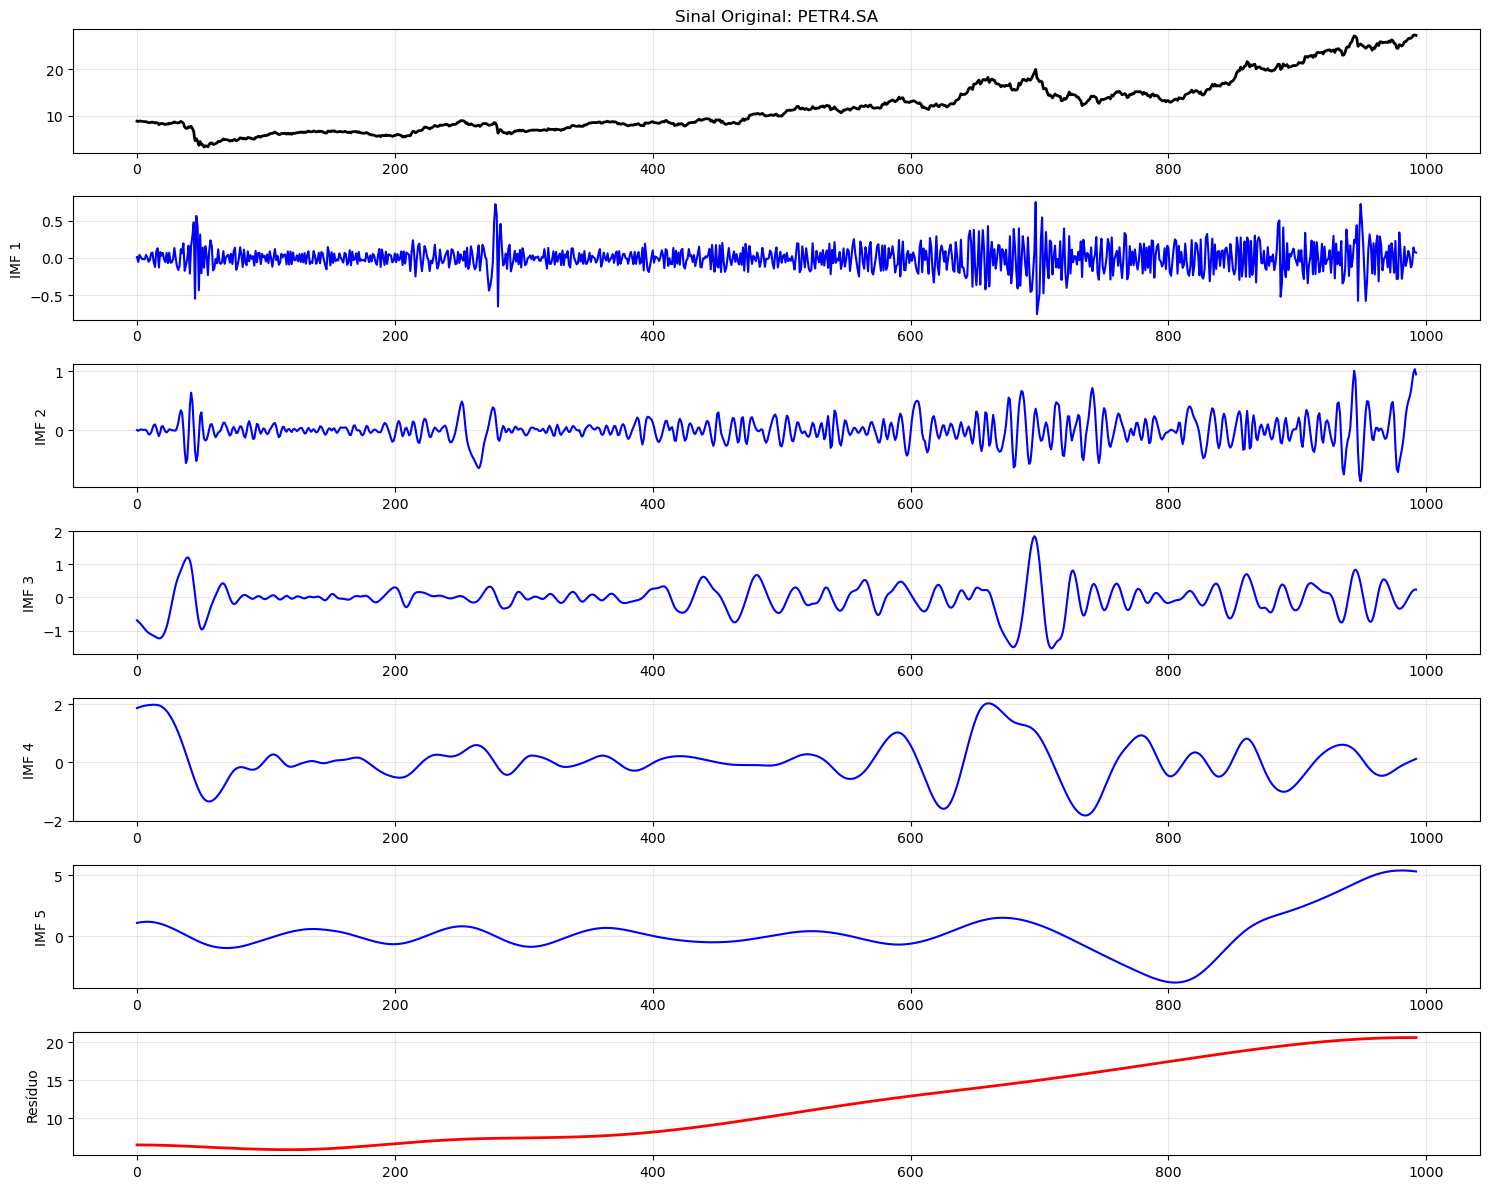

In [5]:
# Plotar todas as IMFs e o resíduo
plt.figure(figsize=(15, num_imfs * 2))
plt.subplot(num_imfs + 1, 1, 1)
plt.plot(t, prices, 'k', linewidth=2)
plt.title(f'Sinal Original: {ticker}')
plt.grid(True, alpha=0.3)

for i in range(num_imfs - 1):
    plt.subplot(num_imfs + 1, 1, i + 2)
    plt.plot(t, imfs[i], 'b')
    plt.ylabel(f'IMF {i+1}')
    plt.grid(True, alpha=0.3)

plt.subplot(num_imfs + 1, 1, num_imfs + 1)
plt.plot(t, imfs[-1], 'r', linewidth=2) # Última IMF é o resíduo
plt.ylabel('Resíduo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


$\quad$ Na prática, o CEEMDAN funciona como um banco de filtros no domínio da frequência. Cada IMF captura processos cíclicos dentro de uma faixa específica de tempo, desde o ruído de alta frequência até as tendências de longo prazo. Uma vantagem crucial é que esse sistema não exige que a tendência geral do gráfico seja removida antes da análise. Assim, conseguimos isolar os componentes do sinal para identificar onde reside a energia do sistema.

$\quad$ Com os modos fundamentais isolados, aplicamos a Transformada de Hilbert a cada IMF para construir um sinal analítico complexo. A partir desse sinal, extraímos a frequência instantânea, definida matematicamente como a derivada temporal da função de fase da oscilação. Ao contrário da análise de Fourier tradicional, que assume frequências constantes e globais, a frequência instantânea permite descrever as mudanças locais e dinâmicas no ritmo das flutuações da PETR4, capturando a essência de um sistema físico que é inerentemente não linear e não estacionário.

$\quad$ Essa análise resulta no Espectro de Hilbert, um mapa que distribui a energia (quadrado da amplitude instantânea) através do plano tempo-frequência. No contexto deste problema, a amplitude de energia representa a intensidade de uma oscilação específica em um dado momento. Fisicamente, identificar onde a energia está concentrada nos permite separar o "sinal" real da "fricção" do sistema: as componentes que apresentam alta amplitude de energia em frequências mais baixas revelam as tendências robustas e persistentes do ativo. Por outro lado, oscilações com baixa energia e frequências erráticas são tratadas como ruído estocástico, permitindo que a filtragem física limpe o sinal antes que ele seja processado pela nossa rede neural LSTM.

$\quad$ Usando a biblioteca `SciPy`, temos como objetivo dessa etapa calcular a amplitude (energia) e a frequência instantânea de cada componente, permitindo mapear como a intensidade e a velocidade das oscilações da PETR4 evoluem ao longo do tempo.

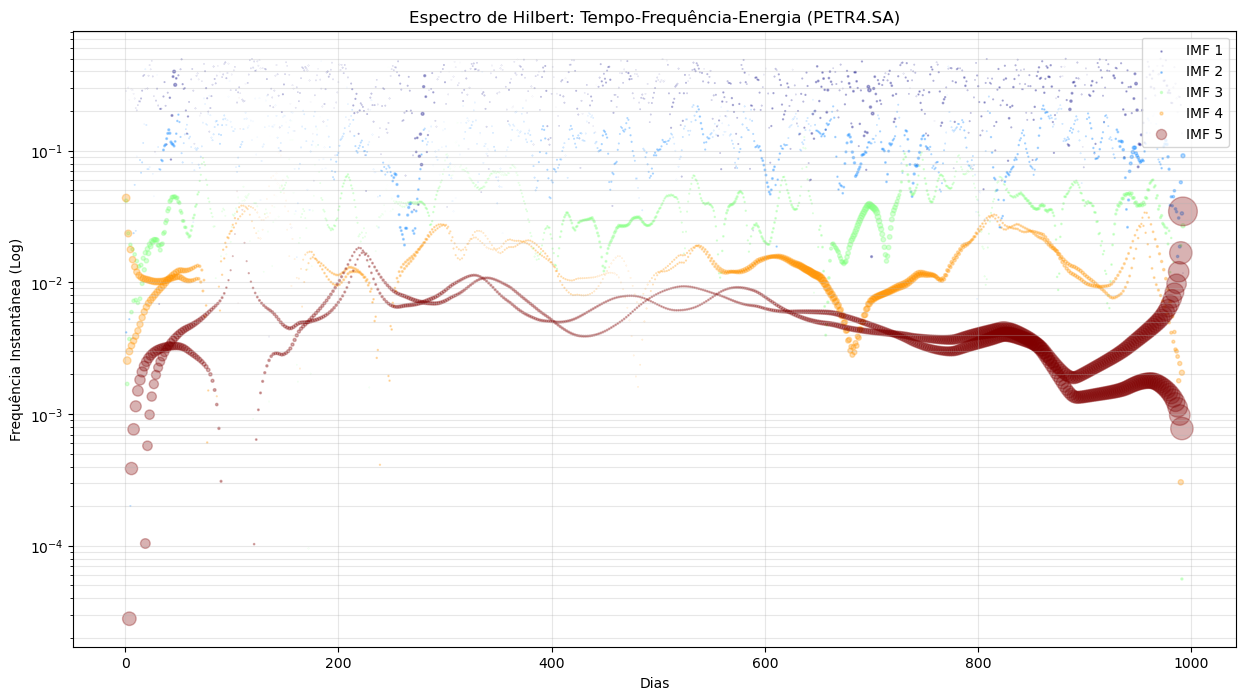

In [6]:
plt.figure(figsize=(15, 8))
colors = cm.jet(np.linspace(0, 1, num_imfs - 1))
mean_frequencies = []

# Loop calcula a transformada, plota o espectro e extrai as médias
for i in range(num_imfs - 1):
    # 1. Obtenção da Cinemática da Onda via Sinal Analítico Complexo
    analytic_signal = hilbert(imfs[i])
    amplitude = np.abs(analytic_signal)
    
    # Derivada da fase para encontrar a Frequência Instantânea
    phase = np.unwrap(np.angle(analytic_signal))
    frequency = np.diff(phase) / (2.0 * np.pi)
    
    # 2. Plot do Espectro de Hilbert (Tamanho do ponto = Energia da onda)
    energy = amplitude[1:]**2
    plt.scatter(t[1:], frequency, c=[colors[i]], s=energy * 5, alpha=0.3, label=f'IMF {i+1}')
    
    # 3. Guarda a Frequência Média para usar no Filtro Passa-Baixa
    valid_freqs = frequency[frequency > 0] # Remove ruído numérico espúrio
    if len(valid_freqs) > 0:
        mean_frequencies.append(np.mean(valid_freqs))
    else:
        mean_frequencies.append(0)

plt.yscale('log')
plt.title(f'Espectro de Hilbert: Tempo-Frequência-Energia ({ticker})')
plt.xlabel('Dias')
plt.ylabel('Frequência Instantânea (Log)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='upper right', markerscale=0.5)
plt.show()



$\quad$ O gráfico resultante é o Espectro de Hilbert, onde a dispersão dos pontos revela a densidade de energia em diferentes escalas temporais. Pontos maiores indicam momentos de maior volatilidade ou força direcional, servindo como critério físico para identificar quais componentes carregam a tendência principal do ativo. A junção do CEEMDAN com a análise espectral de Hilbert é chamada de Transformada de Hilbert-Huang (HHT). Através dela, utilizamos o Espectro de Hilbert como o argumento físico definitivo para estabelecer o cut-off (ponto de corte) do nosso filtro passa-baixas.

$\quad$ Um filtro passa-baixas é um operador que permite a passagem de sinais com frequências baixas — que representam as tendências macro e a inércia do mercado — enquanto atenua ou elimina as frequências altas, comumente associadas ao ruído estocástico de curtíssimo prazo.

$\quad$ No Espectro de Hilbert, observamos que as primeiras IMFs habitam zonas de frequências extremamente elevadas e possuem dispersão errática de energia. Elas são a "agitação térmica" do sistema. Ao identificar onde essa energia desordenada termina, isolamos o sinal inercial. O filtro, portanto, não é escolhido de forma arbitrária; ele é moldado pela própria dinâmica energética da PETR4, garantindo que apenas os ciclos com densidade de energia relevante sobrevivam para a etapa de modelagem. Neste caso, as IMFs 1 e 2 são descartadas como agitação térmica e o restante será considerado sinal.



--- Frequências Fundamentais (Modos Normais) ---
IMF 1: Frequência Média = 0.2933 ciclos/dia
IMF 2: Frequência Média = 0.1181 ciclos/dia
IMF 3: Frequência Média = 0.0398 ciclos/dia
IMF 4: Frequência Média = 0.0154 ciclos/dia
IMF 5: Frequência Média = 0.0062 ciclos/dia


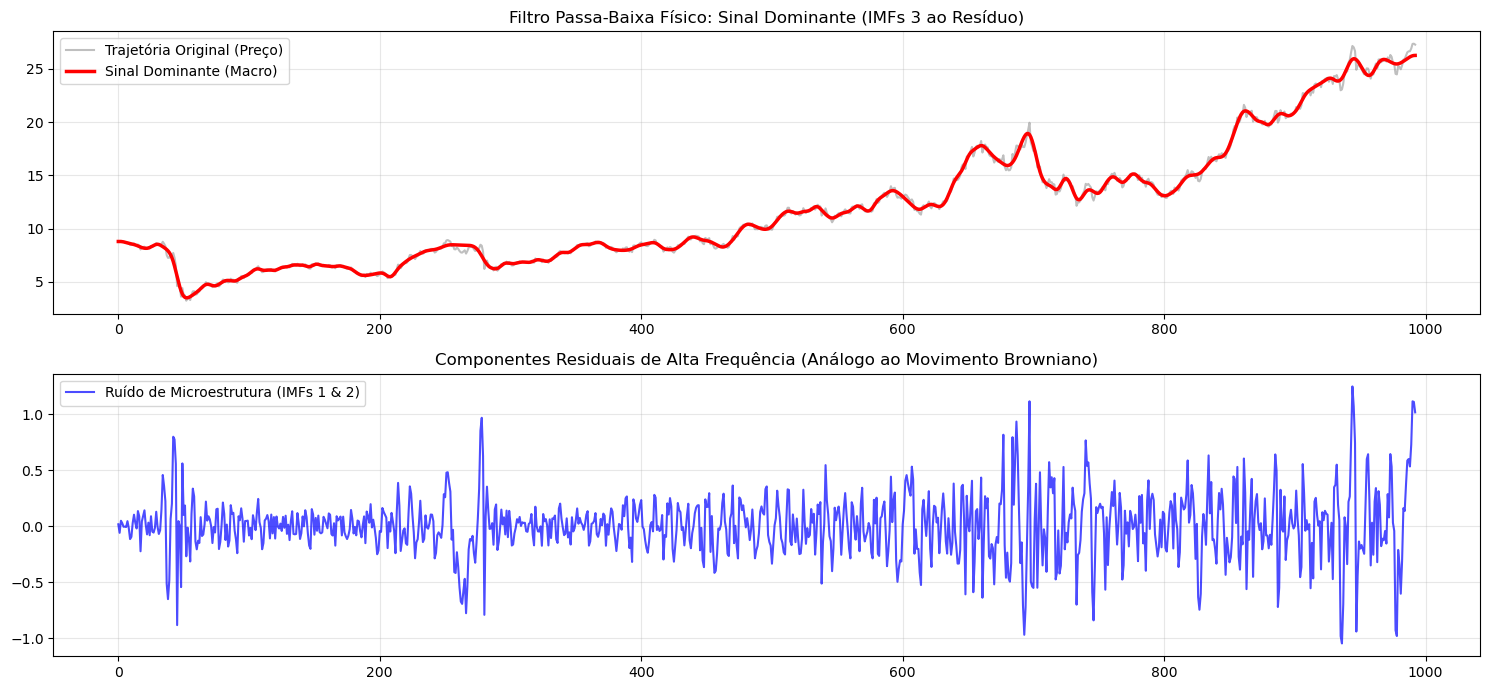

In [7]:
print(f"\n--- Frequências Fundamentais (Modos Normais) ---")
for i, f in enumerate(mean_frequencies):
    print(f"IMF {i+1}: Frequência Média = {f:.4f} ciclos/dia")

# IMFs de altíssima frequência são ruído de microestrutura.
cut_off_index = 2 # IMFs 1 e 2 serão tratadas como "agitação térmica"

# Reconstrução linear 
sinal_dominante = np.sum(imfs[cut_off_index:], axis=0) # O momento inercial real
ruido_residual = np.sum(imfs[:cut_off_index], axis=0)  # O ruído descartado

# Plotando o resultado do filtro
plt.figure(figsize=(15, 7))

# Plot Superior: O Sinal Limpo vs Original
plt.subplot(2, 1, 1)
plt.plot(t, prices, 'gray', alpha=0.5, label='Trajetória Original (Preço)')
plt.plot(t, sinal_dominante, 'r', linewidth=2.5, label='Sinal Dominante (Macro)')
plt.title(f'Filtro Passa-Baixa Físico: Sinal Dominante (IMFs {cut_off_index+1} ao Resíduo)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Inferior: O Ruído Descartado
plt.subplot(2, 1, 2)
plt.plot(t, ruido_residual, 'b', alpha=0.7, label='Ruído de Microestrutura (IMFs 1 & 2)')
plt.title('Componentes Residuais de Alta Frequência (Análogo ao Movimento Browniano)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

$\quad$ Ao observar os gráficos de filtragem, fica evidente que o sinal dominante reconstruído a partir das frequências mais baixas engloba o movimento estrutural do ativo. Enquanto o preço original da Petrobras é bombardeado por flutuações erráticas, essa versão filtrada captura as reversões de tendência e os ciclos que realmente definem a trajetória da ação no longo prazo.

$\quad$ Retirar as ondas de altíssima frequência (o ruído de microestrutura) é um passo fundamental. Ao realizar essa limpeza, eliminamos o caos que forçaria a rede neural a buscar padrões em movimentos puramente aleatórios. Com o sinal ajustado, o modelo consegue identificar dependências temporais sólidas, entregando uma previsão que não se perde em sustos de curto prazo, mas se mantém aderente ao fluxo das grandes tendências.

$\quad$ Definida essa filtragem, o próximo passo é escolher em qual frequência o modelo irá mergulhar. No mercado, as tendências raramente se movem em linhas retas. Elas se comportam como ciclos que ganham e perdem intensidade. Para capturar essa dinâmica, isolamos a IMF 3, que representa o primeiro nível de tendência macro do ativo, já livre das oscilações térmicas iniciais.

$\quad$ O objetivo técnico agora é extrair o envelope da onda, ou seja, sua amplitude instantânea. Na física, essa medida representa a energia do sistema. Em vez de exigir que a rede preveja cada "ziguezague" imprevisível do preço, nós a treinamos para modelar a evolução dessa energia subjacente. É uma troca estratégica: paramos de perseguir o ruído momentâneo para focar na força inercial que empurra o ciclo. Como essa curva de energia é muito mais suave, ela permite que a inteligência artificial entenda a força do movimento antes mesmo que ele mude de direção.

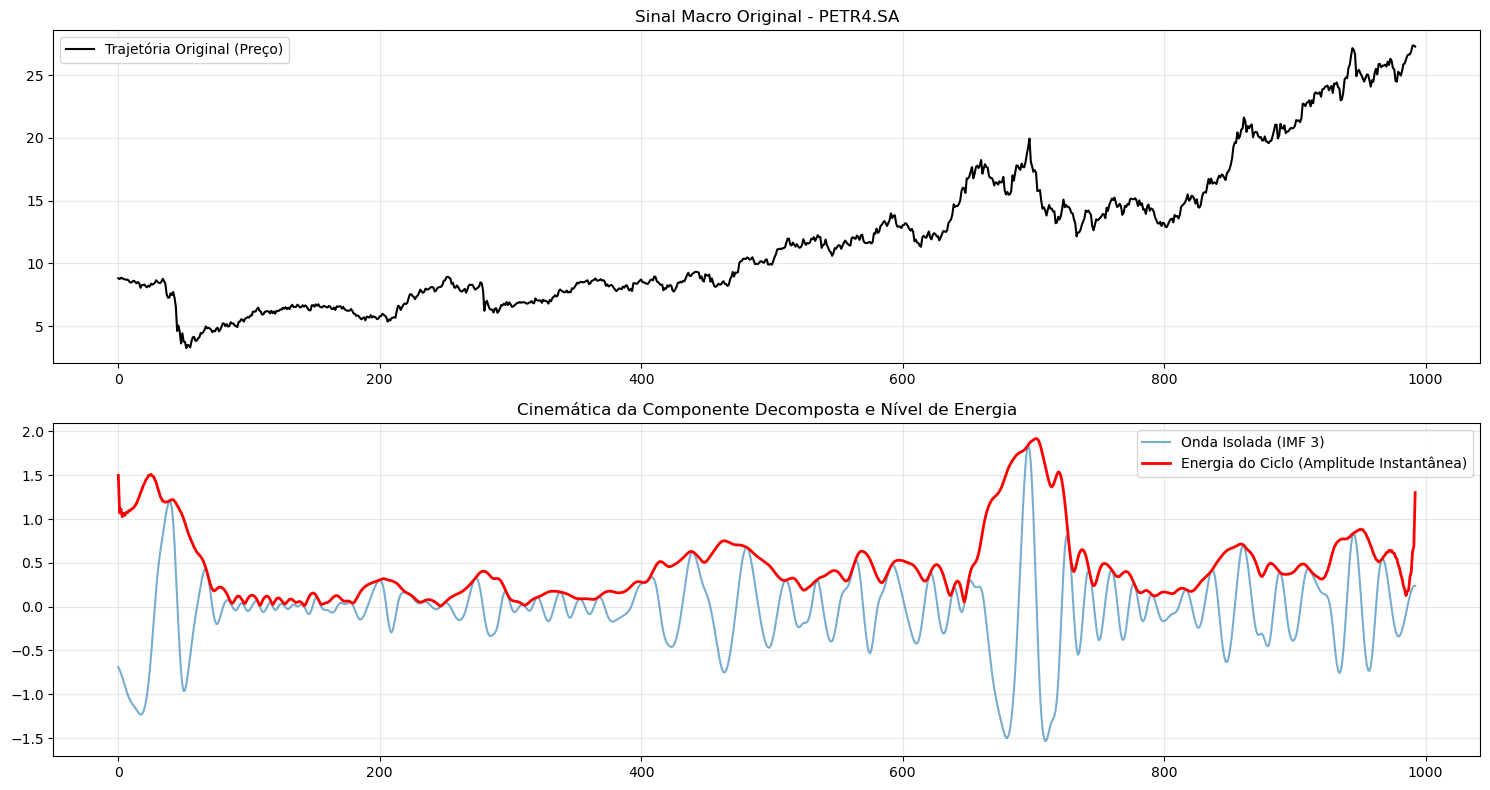

In [8]:
# No bloco anterior, definimos que o ruído termina na IMF 2 (índices 0 e 1).
# Vamos pegar a primeira onda de "tendência macro" (IMF 3, índice 2) para modelar.
target_idx = 2 
imf_signal = imfs[target_idx]

# A Transformada de Hilbert nos dá o envelope da onda (sua Energia/Amplitude atual)
amplitude_instantanea = np.abs(hilbert(imf_signal))

# Visualização: A Onda Isolada e sua Energia Cinética
plt.figure(figsize=(15, 8))

# Plot Superior: Preço Original para referência
plt.subplot(2, 1, 1)
plt.plot(t, prices, label='Trajetória Original (Preço)', color='black')
plt.title(f'Sinal Macro Original - {ticker}')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Inferior: A onda pura e a curva de energia que a LSTM vai prever
plt.subplot(2, 1, 2)
plt.plot(t, imf_signal, label=f'Onda Isolada (IMF {target_idx + 1})', alpha=0.6)
plt.plot(t, amplitude_instantanea, label='Energia do Ciclo (Amplitude Instantânea)', color='red', linewidth=2)
plt.title('Cinemática da Componente Decomposta e Nível de Energia')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

$\quad$ A comparação entre a IMF 3 e sua amplitude instantânea revela a anatomia do movimento. Enquanto a onda oscila entre valores positivos e negativos, a linha vermelha define a estatura dessa oscilação em cada instante. Ela funciona como o esqueleto que sustenta o movimento. Observar as duas curvas juntas garante que o envelope está abraçando a dinâmica real da onda.

$\quad$ Para a rede neural, essa distinção é fundamental. Tentar prever a onda original exigiria que o modelo acertasse o momento exato de cada inversão. Essa é uma tarefa complexa e sujeita a muitos erros de tempo. A linha vermelha descreve a evolução da energia do ciclo de forma contínua e muito mais suave. Ao focar nessa amplitude, entregamos ao modelo uma meta que representa a vitalidade da tendência e não apenas sua posição momentânea. Prever a intensidade do sinal é muito mais robusto do que tentar adivinhar cada ziguezague individual. O resultado é um alvo fisicamente coerente para a inteligência artificial.

## Treinamento da LSTM

$\quad$ Como o final da seção passada indica, agora iremos usar o desenvolvimento físico e as energias encontradas para alimentar uma rede neural. Utilizamos a arquitetura LSTM (Long Short-Term Memory) pela seu desempenho ao lidar com séries temporais de natureza não linear ou não estacionária. Esse modelo é referência em áreas que exigem memória de longo prazo, como o estudo de manchas solares ou padrões climáticos globais.

$\quad$ O diferencial dessa rede está na forma como ela gerencia o fluxo de informações ao longo do tempo. Enquanto modelos convencionais perdem o rastro de dados antigos rapidamente, a LSTM opera com uma estrutura interna que funciona como uma esteira de memória. Três mecanismos, os chamados portões, filtram o que entra e o que sai dessa esteira. O primeiro, o portão de esquecimento, descarta o que perdeu o sentido para o futuro. O segundo seleciona quais novos sinais da energia da Petrobras merecem ser armazenados. Por fim, o portão de saída decide qual parcela desse conhecimento acumulado deve gerar a previsão final. Esse funcionamento pode ser visto na Figura 1.

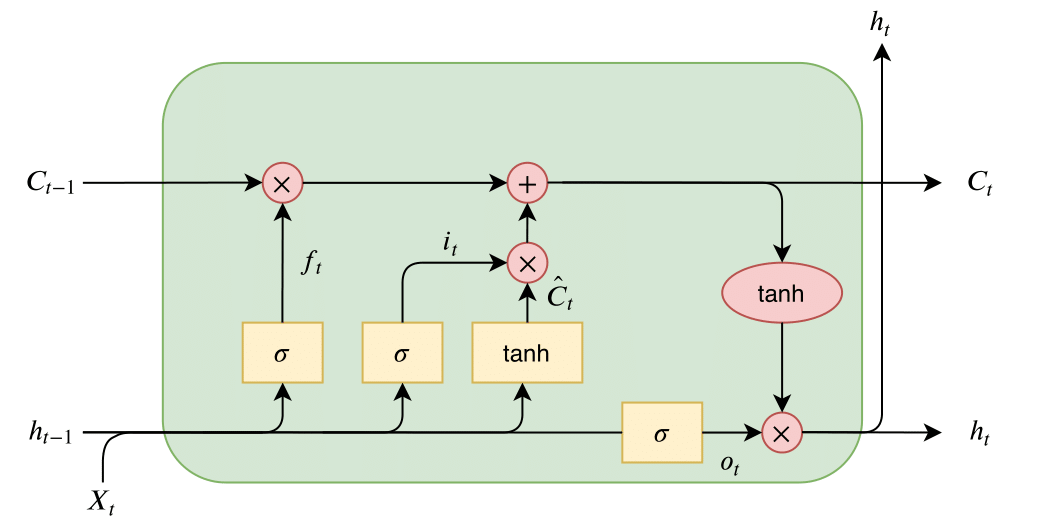
**Figura 1**: Esquematização da arquitetura de funcionamento de uma rede neural do tipo LSTM. O portao do esquecimento, representado pelo $f_t$; o portão da memória, pelo $i_t$; e o que decide qual parecela gera a previsão $\hat C_t$; e por fim, o output representado por $o_t$. [Créditos da imagem: Saba Hesaraki]

$\quad$ Essa arquitetura permite que a rede capture a inércia do mercado com precisão cirúrgica. Como o nosso alvo é a curva de energia, a inteligência artificial consegue enxergar o fôlego acumulado nos últimos quinze dias. Ela detecta se o ciclo está ganhando tração ou se aproxima de um ponto de exaustão. Em vez de apenas reagir ao preço atual, a rede compreende o contexto completo do movimento. O resultado é uma previsão muito mais estável, conectada à realidade física das tendências financeiras e protegida contra oscilações sem fundamento.

$\quad$ Aqui iremos utilizar a biblioteca `PyTorch` para a construção e treinamento da rede neural. Com isso, precisamos inicialmete pré-processar os dados. O primeiro passo é separar os dados brutos em $80\%$ para treino e $20\%$ para teste. Essa divisão no inicio do pre-processamento é crucial para evitar o vazamento de dados (*data leakage*), garantindo que o modelo nao tenha acesso antecipado a informações que ele não deveria conhecer.

$\quad$ A normalização da energia agora é aplicada para o intervalo entre 0 e 1. O `scaler` aprende os limites de máximo e mínimo apenas no conjunto de treino. Para os dados de teste, aplicamos apenas a transformação baseada nessa "régua" do passado. Esse ajuste de escala evita instabilidades no treinamento, como a explosão de valores numéricos.

$\quad$ Por fim, a função `create_sequences` estrutura a memória da rede em janelas deslizantes de 15 dias. Esse formato ensina a LSTM a olhar para o rastro da inércia passada para projetar o próximo passo do ciclo. O resultado são tensores do PyTorch prontos para o treinamento, permitindo que a inteligência artificial identifique se a força da tendência está em ascensão ou em declínio.


In [13]:
# Separação dos dados brutos (80% Treino, 20% Teste)
split_idx = int(0.8 * len(amplitude_instantanea))
train_data = amplitude_instantanea[:split_idx].reshape(-1, 1)
test_data = amplitude_instantanea[split_idx:].reshape(-1, 1)

# Normalização Rigorosa (Aprende só com o treino, aplica em ambos)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data) # Apenas transform, sem fit!

# Função para criar as janelas deslizantes (Lookback)
def create_sequences(data, lookback=15):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

# Geração dos tensores finais
X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

print(f"Dimensões do Tensor de Treino (X): {X_train.shape}")
print(f"Dimensões do Tensor de Teste (X): {X_test.shape}")

Dimensões do Tensor de Treino (X): torch.Size([779, 15, 1])
Dimensões do Tensor de Teste (X): torch.Size([184, 15, 1])


$\quad$ Com os tensores prontos, construímos a arquitetura da LSTM para iniciar o treinamento. O modelo processa a memória dos 15 dias de lookback e utiliza o erro quadrático médio (MSE) como bússola para ajustar seus parâmetros. A curva de aprendizado abaixo monitora a *loss*, que representa a diferença entre a previsão da rede e a energia real do ciclo. Conforme essa métrica diminui, o modelo refina seu entendimento sobre a inércia do sinal, indicando que a inteligência artificial está convergindo para uma representação fiel da dinâmica da Petrobras.

Epoch [10/60], Loss: 0.018818
Epoch [20/60], Loss: 0.005759
Epoch [30/60], Loss: 0.003727
Epoch [40/60], Loss: 0.002520
Epoch [50/60], Loss: 0.001780
Epoch [60/60], Loss: 0.001541


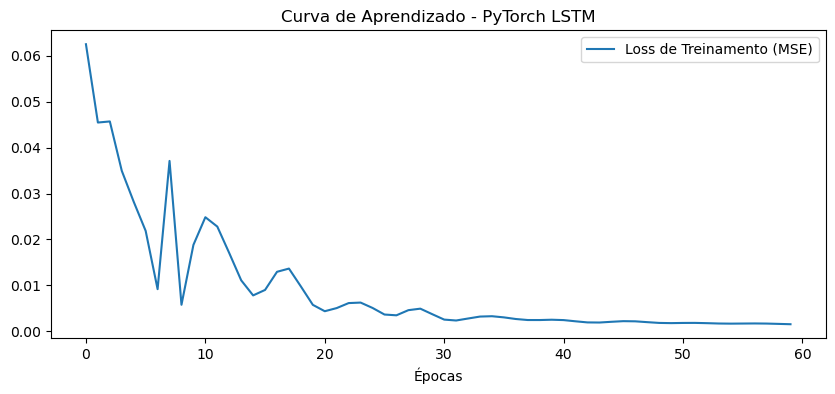

In [14]:
# Definição da Arquitetura LSTM
class HHT_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(HHT_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :]) # Pega apenas o último time-step
        return out

model = HHT_LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Loop de Treinamento
epochs = 60
losses = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Visualização do Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Loss de Treinamento (MSE)')
plt.title('Curva de Aprendizado - PyTorch LSTM')
plt.xlabel('Épocas')
plt.legend()
plt.show()

$\quad$ Após o treinamento, seguimos para a validação do modelo. No bloco de código a seguir, testamos se a rede LSTM consegue prever o comportamento da Petrobras em um cenário que ela nunca viu antes, validado se a estrutura física que isolamos é realmente persistente.

$\quad$ Os comandos `model.eval()` e `torch.no_grad()` colocam a rede em modo determinístico, desativando dropout e o cálculo de gradientes para garantir uma avaliação correta. Em seguida, as previsões normalizadas são convertidas de volta para a escala original com inverse_transform, permitindo comparar diretamente os valores previstos com a amplitude real da série.

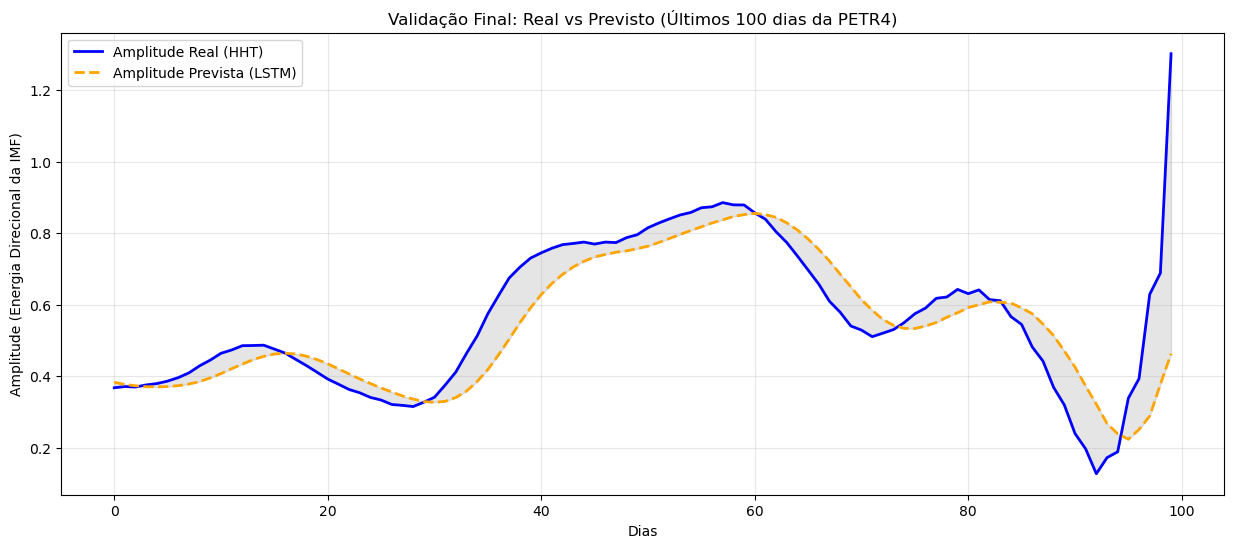

In [17]:
# Colocar o modelo em modo de avaliação (desativa Dropouts, congela pesos)
model.eval()

# Realizar a predição sem calcular gradientes
with torch.no_grad():
    # Previsão apenas no conjunto de TESTE para as métricas matemáticas
    test_predictions_scaled = model(X_test).numpy()
    
    # Previsão em TODO o conjunto X para o gráfico contínuo
    all_predictions_scaled = model(X).numpy()

# Inverter a escala para voltar aos valores originais de amplitude (Energia)
test_predictions = scaler.inverse_transform(test_predictions_scaled)
real_test = scaler.inverse_transform(y_test.numpy())

all_predictions = scaler.inverse_transform(all_predictions_scaled)
real_all = scaler.inverse_transform(y.numpy())

# Visualização do Resultado (Focando nos últimos 100 dias - Região não vista)
plt.figure(figsize=(15, 6))

# Pegamos os últimos 100 dias do conjunto completo para plotar
plt.plot(real_all[-100:], label='Amplitude Real (HHT)', color='blue', linewidth=2)
plt.plot(all_predictions[-100:], label='Amplitude Prevista (LSTM)', color='orange', linestyle='--', linewidth=2)

# Destacar a diferença (Erro) visualmente
plt.fill_between(range(100), real_all[-100:].flatten(), all_predictions[-100:].flatten(), color='gray', alpha=0.2)

plt.title(f'Validação Final: Real vs Previsto (Últimos 100 dias da PETR4)')
plt.xlabel('Dias')
plt.ylabel('Amplitude (Energia Direcional da IMF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



$\quad$ O gráfico acima foca nos últimos 100 dias da série, permitindo uma análise visual direta entre a linha azul, que representa o comportamento real da energia da PETR4, e a linha laranja, que traduz a tentativa da rede de mapear o movimento do ativo. Como a projeção laranja acompanha a tendência da azul, o modelo prova que a decomposição Hilbert-Huang foi capaz de extrair uma espinha dorsal persistente e previsível. Essa aderência à realidade estrutural confirma que o sistema capturou a inércia do mercado, preparando o terreno para o cálculo das métricas de erro que darão o selo final de precisão ao trabalho.

$\quad$ Com essa validação visual concluída, avançamos para o cálculo das métricas de erro, onde transformaremos essa percepção em números definitivos de precisão.

In [18]:
# Cálculo das métricas de erro (ESTRITAMENTE NO CONJUNTO DE TESTE)
rmse = np.sqrt(mean_squared_error(real_test, test_predictions))
mape = mean_absolute_percentage_error(real_test, test_predictions) * 100

# Diagnóstico do Modelo
print(f"--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")
print(f"Erro Percentual Absoluto (MAPE): {mape:.2f}%")

--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---
Erro Médio Quadrático (RMSE): 0.0963
Erro Percentual Absoluto (MAPE): 13.11%



--- Diagnóstico Físico do Mercado (Sinal Quant) ---
SINAL: Expansão de Energia. A inércia da tendência atual está ganhando força.


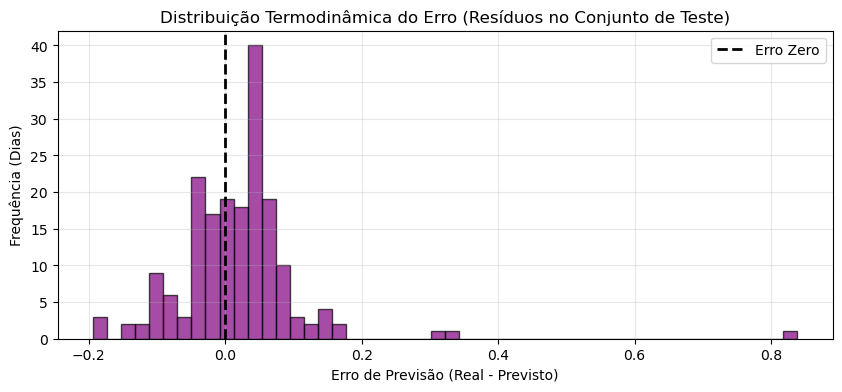

In [16]:
# ==============================================================================
# BLOCO D: APLICAÇÃO QUANT E DIAGNÓSTICO ESTATÍSTICO
# ==============================================================================

# 1. Diagnóstico de Momentum (Avaliando a Derivada da Energia)
amp_hoje = all_predictions[-2][0]   # Penúltimo dia da nossa série
amp_amanha = all_predictions[-1][0] # Último dia (previsão mais recente)

print(f"\n--- Diagnóstico Físico do Mercado (Sinal Quant) ---")
if amp_amanha > amp_hoje:
    print("SINAL: Expansão de Energia. A inércia da tendência atual está ganhando força.")
else:
    print("SINAL: Exaustão de Ciclo. A onda está perdendo energia (possível reversão).")

# 2. Visualização da Termodinâmica do Erro (Resíduos)
# Calculamos os resíduos APENAS nos dados não vistos (Teste) para rigor científico
residuals = real_test - test_predictions

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='black', linestyle='dashed', linewidth=2, label='Erro Zero') # Linha central
plt.title('Distribuição Termodinâmica do Erro (Resíduos no Conjunto de Teste)')
plt.xlabel('Erro de Previsão (Real - Previsto)')
plt.ylabel('Frequência (Dias)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()